In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd

In [ ]:
import os, glob
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/TF-PINN/PINN-vibraciones_prueba-y-evaluacion/parametros/data_fem


/content/drive/MyDrive/Colab Notebooks/TF-PINN/PINN-vibraciones_prueba-y-evaluacion/parametros/data_fem


In [ ]:
data = pd.read_csv(r'data_fem/resultados_20dot20_10s.dat', delim_whitespace=True)
data.info()

/tmp/ipython-input-3001010694.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(r'resultados_carlos_20dot20_10s.dat', delim_whitespace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10201 entries, 0 to 10200
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x              10201 non-null  float64
 1   t              10201 non-null  float64
 2   displacements  10201 non-null  float64
 3   rotations      10201 non-null  float64
 4   f              10201 non-null  float64
 5   k_LL           10201 non-null  float64
 6   k_LR           10201 non-null  float64
 7   k_RL           10201 non-null  float64
 8   k_RR           10201 non-null  float64
dtypes: float64(9)
memory usage: 717.4 KB


In [ ]:
data.head()

,x,t,displacements,rotations,f,k_LL,k_LR,k_RL,k_RR
0,0.00,0.0,0.0,0.0,0.0,700000.0,1.000000e+10,90000.0,90000.0
1,0.01,0.0,0.0,0.0,0.0,700000.0,1.000000e+10,90000.0,90000.0
2,0.02,0.0,0.0,0.0,0.0,700000.0,1.000000e+10,90000.0,90000.0
3,0.03,0.0,0.0,0.0,0.0,700000.0,1.000000e+10,90000.0,90000.0
4,0.04,0.0,0.0,0.0,0.0,700000.0,1.000000e+10,90000.0,90000.0


In [ ]:
x = data['x'].to_numpy()
t = data['t'].to_numpy()
w = data['displacements']
psi = data['rotations']
f = data['f']


In [ ]:

#  Extraer valores únicos de x y t
x_unique = np.sort(data['x'].unique())
t_unique = np.sort(data['t'].unique())

# Crear mallas de x y t
X, T = np.meshgrid(x_unique, t_unique)

# Crear mallas de w y psi
# Suponiendo que cada combinación (x, t) tiene un único valor de w y psi
# Reorganizamos los datos en forma de matriz

# Pivotear los datos para obtener las mallas
W = data.pivot(index='t', columns='x', values='displacements').values
Psi = data.pivot(index='t', columns='x', values='rotations').values


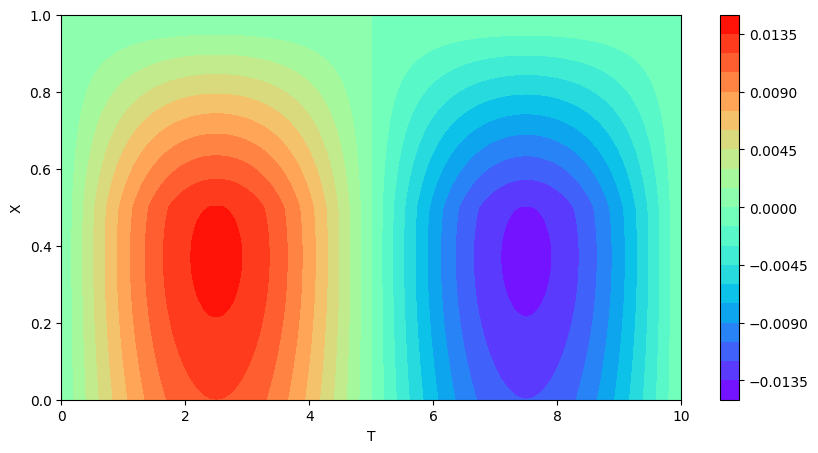

In [ ]:

fig, ax = plt.subplots(figsize=(10,5))
heatmap = ax.contourf(T, X, W, levels=25, cmap='rainbow')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical')
ax.set_xlabel('T')
ax.set_ylabel('X')
plt.show()


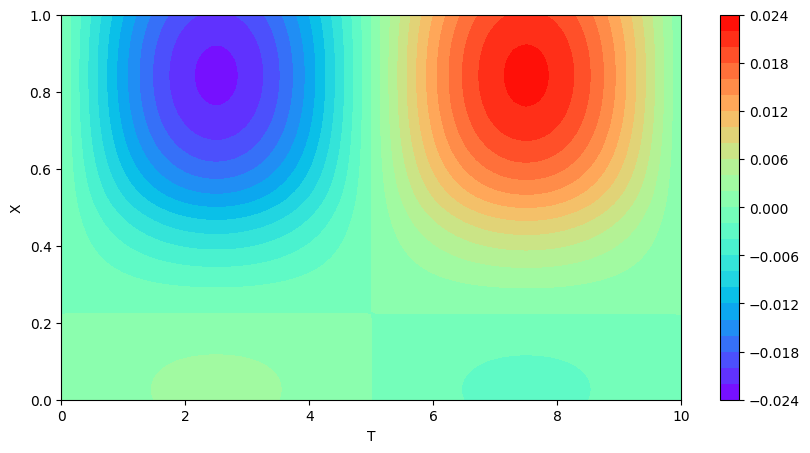

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
heatmap = ax.contourf(T, X, Psi, levels=25, cmap='rainbow')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical')
ax.set_xlabel('T')
ax.set_ylabel('X')
plt.show()